# Notebook 21 — "Noisy Directional" Class Refinement + Open Questions

**Phase 2b follow-up** — Four open questions from nb20 (Chronos):

1. **"Noisy directional" class refinement** — three sub-types emerging. Test with three targeted new datasets.
2. **Sea_level density artifact test** — is sea_level's Chronos isolation real, or a data-count artifact (31 vs 120+ instances)?
3. **cl6 characterization** — what do VIX + ENSO + temperature share that Chronos is responding to?
4. **Mirror distortion invariance** — do time-reversal / amplitude-flip preserve cluster membership in Chronos space?

---

## Pre-run Predictions

| Dataset | Expected class | Reasoning |
|---|---|---|
| Atmospheric CH4 trend (NOAA) | keeling_trend-like (clean monotonic) | Deseasonalised methane rise: smooth, unidirectional, minimal residual noise. Should be the cleanest monotonic trend in the corpus. |
| Ocean heat content | temperature-like (noisy directional) | Strong upward signal + interannual variability. Same forcing mechanism as temperature anomaly. |
| Arctic sea ice | NEW class or keeling_seasonal-like | Long-term decline *embedded inside* a strong seasonal cycle. Neither pure trend nor pure oscillator. May form its own class: "declining oscillator". |

**For sea_level density test:** Prediction — isolation is real. Sea_level's smooth altimetry trend is structurally different from temperature's noisy record, not just smaller in count. Chronos should separate them even after density is equalized.

**Note on CH4 replacement:** Glacier mass balance OWID URL returned 404. Replaced with NOAA atmospheric methane trend (deseasonalised). Same scientific test: does a clean monotonic signal land in the keeling_trend class?

**For cl6 (VIX + ENSO + temperature):** Prediction — all three share irregular low-frequency oscillations with moderate autocorrelation. Not strongly periodic (unlike sunspot/lynx_hare), not monotone, not episodic. The "irregular oscillatory" label is what Chronos is detecting.

**For mirror distortions:** Prediction — Chronos is time-direction sensitive. A time-reversed keeling_trend (series goes DOWN over time) will land near COVID or burst-class, not back in keeling_trend. Amplitude-flip (negation) will be less disruptive for symmetric oscillators (sunspot, lynx_hare) than for asymmetric trends.

In [2]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import hdbscan
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from chronos import ChronosPipeline
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SPECTRAL_COLS = ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
ALL_COLS = TIMEDOM_COLS + SPECTRAL_COLS
TARGET_LEN = 64

print(f'PyTorch {torch.__version__}')
print(f'Target series length: {TARGET_LEN} points')

PyTorch 2.11.0+cu130
Target series length: 64 points


In [3]:
# ============================================================
# HELPERS
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def baseline_delta(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))


def spectral_features_fixed(series):
    s = zscore_normalize(np.asarray(series, dtype=float))
    n = len(s)
    fft_vals = np.fft.rfft(s)
    power    = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(n)
    power_ac = power[1:]
    freqs_ac = freqs[1:]
    total_ac = power_ac.sum() if power_ac.sum() > 0 else 1.0
    dom_freq = float(freqs[np.argmax(power)])
    p_norm = power_ac / total_ac
    p_norm = p_norm[p_norm > 0]
    sp_ent = float(-np.sum(p_norm * np.log(p_norm)))
    sp_ent /= np.log(len(power_ac)) if len(power_ac) > 1 else 1.0
    n_ac   = len(freqs_ac)
    low_end = int(n_ac * 0.20)
    mid_end = int(n_ac * 0.60)
    return {
        'dominant_freq':   dom_freq,
        'spectral_entropy': sp_ent,
        'power_low':  float(power_ac[:low_end].sum()  / total_ac),
        'power_mid':  float(power_ac[low_end:mid_end].sum() / total_ac),
        'power_high': float(power_ac[mid_end:].sum()  / total_ac),
    }


def extract_all_features(series):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n, t = len(arr), np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    td = {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': float(np.sum(np.diff(np.sign(arr)) != 0) / n),
        'slope':          float(stats.linregress(t, arr).slope),
        'baseline_delta': baseline_delta(arr),
    }
    return {**td, **spectral_features_fixed(arr)}


def resample_series(series, target_length=TARGET_LEN):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n = len(arr)
    if n == target_length:
        return arr
    x_old = np.linspace(0, 1, n)
    x_new = np.linspace(0, 1, target_length)
    return interp1d(x_old, arr, kind='linear')(x_new)

# ---- Pre-initialise all dataset variables ----
# Each dataset cell overwrites these. If a cell fails or is skipped,
# COMBINE still finds a valid (empty) variable and continues.
_empty_raw = np.zeros((0, TARGET_LEN))
for _v in ['df_covid_all','df_ss_all','df_lh_all','df_k_all','df_temp_all',
           'df_ecg_all','df_sf_all','df_sl_all','df_oni_all','df_vix_all',
           'df_ch4_all','df_ohc_all','df_ice_all']:
    globals()[_v] = pd.DataFrame()
for _v in ['raw_covid','raw_ss','raw_lh','raw_k','raw_temp',
           'raw_ecg','raw_sf','raw_sl','raw_oni','raw_vix',
           'raw_ch4','raw_ohc','raw_ice']:
    globals()[_v] = _empty_raw.copy()
del _v, _empty_raw

print('Helpers OK — all dataset vars pre-initialised')

Helpers OK — all dataset vars pre-initialised


In [4]:
# ============================================================
# DATASET 1: COVID (first + second wave)
# ============================================================
dest = RAW_DIR / 'owid_covid.csv'
if not dest.exists():
    r = requests.get('https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv', stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
df_raw = pd.read_csv(dest, usecols=['location','date','new_cases_smoothed_per_million','continent'], parse_dates=['date'])
df_covid = df_raw.dropna(subset=['continent']).rename(columns={'new_cases_smoothed_per_million':'cases_pm'})

def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if not len(starts): return None
    start = starts[0]
    wave = s[start:min(start+max_days, len(s))]
    if len(wave) < min_days: return None
    peaks, _ = find_peaks(wave, prominence=wave.max()*0.2)
    if not len(peaks): return None
    wave = wave[:min(peaks[0]+60, len(wave))]
    return wave if len(wave) >= min_days else None

def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max()*0.15, distance=45)
    if len(peaks) < 2: return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    wave = s[start:min(peaks[1]+60, len(s))]
    return wave if len(wave) >= min_days else None

records, raw_series = [], []
for country, grp in df_covid.groupby('location'):
    grp = grp.sort_values('date')
    for fn, ds in [(extract_first_wave,'covid_first_wave'), (extract_second_wave,'covid_second_wave')]:
        w = fn(grp['cases_pm'])
        if w is not None:
            feats = extract_all_features(w)
            feats.update({'country': country, 'dataset': ds, 'n_points': len(w)})
            records.append(feats)
            raw_series.append(resample_series(w))
df_covid_all = pd.DataFrame(records)
raw_covid = np.stack(raw_series)
print(df_covid_all['dataset'].value_counts().to_dict(), f'  raw shape: {raw_covid.shape}')

{'covid_second_wave': 209, 'covid_first_wave': 202}   raw shape: (411, 64)


In [5]:
# ============================================================
# DATASET 2: Sunspot cycles
# ============================================================
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv').content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
minima, _ = find_peaks(-smoothed, distance=80)
cycles = {}
for i in range(len(minima)-1):
    c = series_full[minima[i]:minima[i+1]]
    if len(c) >= 80: cycles[f'cycle_{i+1}_{int(df_ss["year"].iloc[minima[i]])}'] = c
records, raw_series = [], []
for name, c in cycles.items():
    feats = extract_all_features(c)
    feats.update({'country': name, 'dataset': 'sunspot_cycle', 'n_points': len(c)})
    records.append(feats)
    raw_series.append(resample_series(c))
df_ss_all = pd.DataFrame(records)
raw_ss = np.stack(raw_series)
print(f'Sunspot: {len(df_ss_all)} cycles  raw shape: {raw_ss.shape}')

Sunspot: 24 cycles  raw shape: (24, 64)


In [6]:
# ============================================================
# DATASET 3: Lynx-hare
# ============================================================
df_lh = pd.read_csv(Path('../datasets/lynx_hare/lynx_hare.csv'))
year_col = [c for c in df_lh.columns if c.lower()=='year'][0]
species_cols = [c for c in df_lh.columns if c.lower()!='year']
window_size = 10
series_dict = {}
for sp in species_cols:
    full = df_lh[sp].values.astype(float)
    series_dict[f'{sp}_full'] = full
    for start in range(len(full)-window_size+1):
        series_dict[f'{sp}_w{start}_{df_lh[year_col].iloc[start]}'] = full[start:start+window_size]
records, raw_series = [], []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': 'lynx_hare', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_lh_all = pd.DataFrame(records)
raw_lh = np.stack(raw_series)
print(f'Lynx-hare: {len(df_lh_all)}  raw shape: {raw_lh.shape}')

Lynx-hare: 26  raw shape: (26, 64)


In [7]:
# ============================================================
# DATASET 4: Keeling CO2 (seasonal + trend)
# ============================================================
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv').content)
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
for col in ['year','month','average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year','month','average'])
co2 = co2[co2['average']>0].copy()
co2.index = pd.to_datetime({'year':co2['year'].astype(int),'month':co2['month'].astype(int),'day':1})
result = seasonal_decompose(co2['average'], model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals    = result.trend.dropna().values
start_year    = co2.index.min().year
series_dict = {}
for i in range(len(seasonal_vals)//12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg)==12: series_dict[f'keeling_seasonal_{start_year+i}'] = (seg, 'keeling_seasonal')
for i in range(0, len(trend_vals)-120, 12):
    series_dict[f'keeling_trend_{start_year+i//12}'] = (trend_vals[i:i+120], 'keeling_trend')
records, raw_series = [], []
for name, (s, ds) in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': ds, 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_k_all = pd.DataFrame(records)
raw_k = np.stack(raw_series)
print(df_k_all['dataset'].value_counts().to_dict(), f'  raw shape: {raw_k.shape}')

{'keeling_seasonal': 68, 'keeling_trend': 58}   raw shape: (126, 64)


In [8]:
# ============================================================
# DATASET 5: Global temperature anomaly
# ============================================================
dest = RAW_DIR / 'temperature_anomaly.csv'
if not dest.exists():
    r = requests.get('https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
                     headers={'User-Agent':'Mozilla/5.0'}, timeout=30)
    r.raise_for_status()
    dest.write_bytes(r.content)
with open(dest) as f: raw = f.read()
if raw.lstrip().startswith('%'):
    rows = []
    for line in raw.splitlines():
        if line.strip() and not line.strip().startswith('%'):
            parts = line.split()
            if len(parts)>=2:
                try: rows.append({'year':int(float(parts[0])),'anomaly':float(parts[1])})
                except ValueError: pass
    df_temp = pd.DataFrame(rows).dropna()
else:
    lines = raw.splitlines()
    hidx = next(i for i,l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=hidx, na_values=['***','****'])
    df_temp = df_temp[['Year','J-D']].rename(columns={'Year':'year','J-D':'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'],errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'],errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5
records, raw_series = [], []
for i in range(0, len(values)-window, step):
    s = values[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'temp_{years[i]}','dataset':'temperature','n_points':len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_temp_all = pd.DataFrame(records)
raw_temp = np.stack(raw_series)
print(f'Temperature: {len(df_temp_all)}  raw shape: {raw_temp.shape}')

Temperature: 31  raw shape: (31, 64)


In [9]:
# ============================================================
# DATASET 6: ECG (requires ECGFiveDays.zip in data/raw/)
# ============================================================
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'
if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    if dest_dir.exists(): shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z: z.extractall(dest_dir)
else:
    raise RuntimeError('ECGFiveDays.zip not found — place in data/raw/')

def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.lower()=='@data': in_data=True; continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':',1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try: values=[float(x) for x in parts[:-1]]; label=parts[-1]
                    except (ValueError,IndexError): continue
                if values: series_list.append(np.array(values)); labels.append(label.strip())
    return series_list, labels

ts_files = list(dest_dir.rglob('*.ts'))
all_series, all_labels = [], []
for f in ts_files:
    s, l = parse_ts_file(f)
    all_series.extend(s); all_labels.extend(l)
records, raw_series = [], []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = extract_all_features(s)
    feats.update({'country':f'ecg_{i}_c{label}','dataset':'ecg','n_points':len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_ecg_all = pd.DataFrame(records)
raw_ecg = np.stack(raw_series)
print(f'ECG: {len(df_ecg_all)}  kurtosis={df_ecg_all["kurtosis"].mean():.2f}  raw shape: {raw_ecg.shape}')

Cached: ../data/raw/ECGFiveDays
ECG: 884  kurtosis=15.17  raw shape: (884, 64)


In [10]:
# ============================================================
# DATASET 7: Streamflow (USGS)
# ============================================================
STATIONS = {
    '01350000':'mohawk_ny',    '01427207':'delaware_ny', '01491000':'choptank_md',
    '02087500':'neuse_nc',     '02339500':'flint_ga',    '03049000':'allegheny_pa',
    '03611500':'ohio_il',      '05054000':'red_nd',      '05378500':'mississippi_mn',
    '05420500':'mississippi_ia','06289000':'bighorn_mt', '06600000':'missouri_ia',
    '07022000':'mississippi_mo','07289000':'mississippi_ms','08220000':'riogrande_co',
    '09180000':'colorado_ut',  '09380000':'colorado_az', '11530000':'klamath_ca',
    '02427250':'alabama_al',   '12374250':'clearwater_id','14105700':'columbia_or',
    '14179000':'willamette_or','06354000':'cannonball_nd','02479155':'escatawpa_ms',
    '01096500':'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=20) as resp:   # 20s per station
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series: return None
        recs = []
        for v in series[0]['values'][0]['value']:
            try: recs.append({'date':pd.Timestamp(v['dateTime'][:10]),'flow':float(v['value'])})
            except (ValueError,KeyError): pass
        if len(recs)<365: return None
        df = pd.DataFrame(recs).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly)>=60 else None
    except Exception: return None

# Pre-initialise outputs — safe if cell is interrupted
df_sf_all = pd.DataFrame()
raw_sf    = np.zeros((0, TARGET_LEN))

print(f'Fetching {len(STATIONS)} USGS stations (20s timeout each)...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None: flows[name]=s; print(f'  OK {name}')
    else: print(f'  FAIL {name}')

records, raw_series = [], []
for name, series in flows.items():
    log_flow = np.log1p(series.values.astype(float))
    feats = extract_all_features(log_flow)
    feats.update({'country':name,'dataset':'streamflow','n_points':len(log_flow)})
    records.append(feats)
    raw_series.append(resample_series(log_flow))

if records:
    df_sf_all = pd.DataFrame(records)
    raw_sf    = np.stack(raw_series)
print(f'Streamflow: {len(df_sf_all)} stations  raw shape: {raw_sf.shape}')

Fetching 25 USGS stations (20s timeout each)...
  OK mohawk_ny
  OK delaware_ny
  OK choptank_md
  OK neuse_nc
  OK flint_ga
  OK allegheny_pa
  OK ohio_il
  OK red_nd
  OK mississippi_mn
  OK mississippi_ia
  OK bighorn_mt
  OK missouri_ia
  OK mississippi_mo
  OK mississippi_ms
  OK riogrande_co
  OK colorado_ut
  OK colorado_az
  OK klamath_ca
  OK alabama_al
  OK clearwater_id
  OK columbia_or
  OK willamette_or
  OK cannonball_nd
  OK escatawpa_ms
  OK nashua_ma
Streamflow: 25 stations  raw shape: (25, 64)


In [11]:
# ============================================================
# DATASET 8: Sea level (Phase 1b)
# ============================================================
dest = RAW_DIR / 'sea_level_nasa.csv'
if dest.exists(): dest.unlink()
urls = [
    'https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelRise/slr/slr_sla_gbl_keep_all_66.csv',
    'https://sealevel.colorado.edu/files/current/sl_ns_global.txt',
]
content = None
for url in urls:
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        if b'<!' not in r.content[:20]: content = r.content; print(f'OK: {url[:50]}'); break
    except Exception as e: print(f'  {url[:40]}: {e}')
if content is None: raise RuntimeError('Sea level: all URLs failed')
dest.write_bytes(content)
df_sl = pd.read_csv(dest, comment='#')
mission_cols = [c for c in df_sl.columns if c != 'year']
df_sl['gmsl'] = df_sl[mission_cols].mean(axis=1, skipna=True)
df_sl = df_sl[['year','gmsl']].dropna().rename(columns={'year':'year_frac'}).sort_values('year_frac').reset_index(drop=True)
values_sl = df_sl['gmsl'].values
year_fracs = df_sl['year_frac'].values
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_sl)-window, step):
    s = values_sl[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'sl_{int(year_fracs[i])}','dataset':'sea_level','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_sl_all = pd.DataFrame(records)
raw_sl = np.stack(raw_series)
print(f'Sea level: {len(df_sl_all)}  raw shape: {raw_sl.shape}')

OK: https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelR
Sea level: 120  raw shape: (120, 64)


In [12]:
# ============================================================
# DATASET 9: ENSO ONI (Phase 1b)
# ============================================================
dest = RAW_DIR / 'oni_enso.txt'
if not dest.exists():
    r = requests.get('https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt',
                     headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
    r.raise_for_status(); dest.write_bytes(r.content)
rows = []
with open(dest) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4 and not line.strip().startswith('SEAS'):
            try: rows.append({'year': int(parts[1]), 'oni': float(parts[3])})
            except (ValueError, IndexError): pass
df_oni = pd.DataFrame(rows).dropna()
values_oni = df_oni['oni'].values
window, step = 36, 6
records, raw_series = [], []
for i in range(0, len(values_oni)-window, step):
    s = values_oni[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'oni_{df_oni["year"].iloc[i]}','dataset':'enso_oni','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_oni_all = pd.DataFrame(records)
raw_oni = np.stack(raw_series)
print(f'ENSO ONI: {len(df_oni_all)}  raw shape: {raw_oni.shape}')

ENSO ONI: 147  raw shape: (147, 64)


In [13]:
# ============================================================
# DATASET 10: VIX (Phase 1b)
# ============================================================
dest = RAW_DIR / 'vix_fred.csv'
if dest.exists(): dest.unlink()
for name, url in [('cboe-cdn','https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv'),
                   ('cboe-www','https://www.cboe.com/publish/ScheduledTask/MktData/datahouse/vixcurrent.csv')]:
    try:
        r = requests.get(url, headers={'User-Agent':'Mozilla/5.0'}, timeout=60)
        r.raise_for_status()
        if b'<!DOCTYPE' not in r.content[:200] and len(r.content) > 100:
            dest.write_bytes(r.content); print(f'VIX OK ({name})'); break
    except Exception as e: print(f'  {name}: {e}')
else: raise RuntimeError('All VIX sources failed')
df_vix = pd.read_csv(dest, parse_dates=['DATE'], dayfirst=False)
df_vix = df_vix[['DATE','CLOSE']].rename(columns={'DATE':'date','CLOSE':'vix'}).dropna()
df_vix = df_vix.set_index('date').resample('MS').mean().dropna().reset_index()
values_vix = df_vix['vix'].values
window, step = 24, 3
records, raw_series = [], []
for i in range(0, len(values_vix)-window, step):
    s = values_vix[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'vix_{df_vix["date"].iloc[i].year}_{i}','dataset':'vix','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_vix_all = pd.DataFrame(records)
raw_vix = np.stack(raw_series)
print(f'VIX: {len(df_vix_all)}  raw shape: {raw_vix.shape}')

VIX OK (cboe-cdn)
VIX: 137  raw shape: (137, 64)


In [14]:
# ============================================================
# DATASET 11: Atmospheric methane CH4 (NOAA GML global monthly)
# (Phase 2b, new — testing "clean monotonic" sub-type)
# Replaces glacier mass balance (OWID URL dead)
# ============================================================
dest = RAW_DIR / 'ch4_monthly.txt'
if dest.exists(): dest.unlink()
r = requests.get('https://gml.noaa.gov/webdata/ccgg/trends/ch4/ch4_mm_gl.txt',
                 headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print('CH4 OK')

rows = []
for line in r.content.decode('utf-8').splitlines():
    line = line.strip()
    if not line or line.startswith('#'): continue
    parts = line.split()
    if len(parts) >= 7:
        try:
            year, month = int(parts[0]), int(parts[1])
            avg   = float(parts[3])   # monthly mean
            trend = float(parts[5])   # deseasonalised trend
            if avg > 0 and trend > 0:
                rows.append({'year': year, 'month': month, 'average': avg, 'trend': trend})
        except (ValueError, IndexError):
            pass

df_ch4 = pd.DataFrame(rows).sort_values(['year','month']).reset_index(drop=True)
print(f'CH4 data: {len(df_ch4)} monthly values  ({df_ch4["year"].min()}–{df_ch4["year"].max()})')
print(f'Trend range: {df_ch4["trend"].min():.1f}–{df_ch4["trend"].max():.1f} ppb')

# Use the trend column (deseasonalised) — isolates the clean monotonic signal
values_ch4 = df_ch4['trend'].values
years_ch4  = df_ch4['year'].values

# Rolling windows — 120 months (10 years), step 12
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_ch4) - window, step):
    s = values_ch4[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ch4_{years_ch4[i]}', 'dataset': 'ch4_trend', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ch4_all = pd.DataFrame(records)
raw_ch4 = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'CH4 trend: {len(df_ch4_all)} windows  raw shape: {raw_ch4.shape}')

CH4 OK
CH4 data: 509 monthly values  (1983–2025)
Trend range: 1635.1–1939.2 ppb
CH4 trend: 33 windows  raw shape: (33, 64)


In [15]:
# ============================================================
# DATASET 12: Ocean heat content 0-700m (NOAA NCEI quarterly)
# (Phase 2b, new — testing "noisy directional" sub-type)
# ============================================================
dest = RAW_DIR / 'ocean_heat_content.csv'
if dest.exists(): dest.unlink()

url = 'https://www.ncei.noaa.gov/data/oceans/woa/DATA_ANALYSIS/3M_HEAT_CONTENT/DATA/basin/3month/ohc_levitus_climdash_seasonal.csv'
r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print(f'OHC OK ({len(r.content)} bytes)')

# Format: no header, two columns — "YYYY-Q,value"  (Q = 3,6,9,12 for quarters)
rows = []
for line in r.content.decode('utf-8').splitlines():
    line = line.strip()
    if not line: continue
    try:
        date_part, val_part = line.split(',')
        year, quarter = date_part.split('-')
        rows.append({'year': int(year), 'quarter': int(quarter), 'ohc': float(val_part)})
    except (ValueError, IndexError):
        continue

df_ohc = pd.DataFrame(rows).sort_values(['year','quarter']).reset_index(drop=True)
print(f'OHC data: {len(df_ohc)} quarterly values  ({df_ohc["year"].min()}–{df_ohc["year"].max()})')
print(f'OHC range: {df_ohc["ohc"].min():.3f} to {df_ohc["ohc"].max():.3f}')

values_ohc = df_ohc['ohc'].values

# Rolling windows — 80 quarters (~20 years), step 8
window, step = 80, 8
records, raw_series = [], []
for i in range(0, len(values_ohc) - window, step):
    s = values_ohc[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ohc_{df_ohc["year"].iloc[i]}q{df_ohc["quarter"].iloc[i]}',
                  'dataset': 'ocean_heat', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ohc_all = pd.DataFrame(records)
raw_ohc = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Ocean heat: {len(df_ohc_all)} windows  raw shape: {raw_ohc.shape}')

OHC OK (4805 bytes)
OHC data: 284 quarterly values  (1955–2025)
OHC range: -8.007 to 23.254
Ocean heat: 26 windows  raw shape: (26, 64)


In [16]:
# ============================================================
# DATASET 13: Arctic sea ice extent (NSIDC monthly)
# (Phase 2b, new — testing "declining oscillator" hypothesis)
# Data: 12 separate monthly files, one per calendar month
# ============================================================
base_url = 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_{:02d}_extent_v4.0.csv'
all_rows = []
for month in range(1, 13):
    url = base_url.format(month)
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        for line in r.content.decode('utf-8').splitlines():
            line = line.strip()
            if not line or line.startswith('year'): continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 5:
                try:
                    all_rows.append({'year': int(parts[0]), 'month': int(parts[1]), 'extent': float(parts[4])})
                except ValueError:
                    pass
        print(f'  month {month:02d}: OK')
    except Exception as e:
        print(f'  month {month:02d}: FAIL {e}')

df_ice = pd.DataFrame(all_rows)
df_ice = df_ice[df_ice['extent'] > 0].sort_values(['year','month']).reset_index(drop=True)
print(f'Sea ice data: {len(df_ice)} monthly values  ({df_ice["year"].min()}–{df_ice["year"].max()})')

values_ice = df_ice['extent'].values
# Rolling windows — 120 months (10 years), step 12
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_ice) - window, step):
    s = values_ice[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ice_{df_ice["year"].iloc[i]}', 'dataset': 'arctic_sea_ice', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ice_all = pd.DataFrame(records)
raw_ice = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Arctic sea ice: {len(df_ice_all)} windows  raw shape: {raw_ice.shape}')

  month 01: OK
  month 02: OK
  month 03: OK
  month 04: OK
  month 05: OK
  month 06: OK
  month 07: OK
  month 08: OK
  month 09: OK
  month 10: OK
  month 11: OK
  month 12: OK
Sea ice data: 566 monthly values  (1978–2026)
Arctic sea ice: 38 windows  raw shape: (38, 64)


In [17]:
# ============================================================
# COMBINE — feature DataFrame + raw series matrix (aligned)
# ============================================================
df_all = pd.concat([
    df_covid_all, df_ss_all, df_lh_all, df_k_all,
    df_temp_all, df_ecg_all, df_sf_all,
    df_sl_all, df_oni_all, df_vix_all,
    df_ch4_all, df_ohc_all, df_ice_all,         # new Phase 2b datasets
], ignore_index=True)

X_raw_all = np.concatenate([
    raw_covid, raw_ss, raw_lh, raw_k,
    raw_temp, raw_ecg, raw_sf,
    raw_sl, raw_oni, raw_vix,
    raw_ch4, raw_ohc, raw_ice,
], axis=0)

# Drop NaN feature rows (keep aligned)
valid_mask = df_all[ALL_COLS].notna().all(axis=1).values
df_all     = df_all[valid_mask].reset_index(drop=True)
X_raw_all  = X_raw_all[valid_mask]

DATASETS = sorted(df_all['dataset'].unique())
ORIG_9   = ['covid_first_wave','covid_second_wave','ecg','keeling_seasonal',
             'keeling_trend','lynx_hare','streamflow','sunspot_cycle','temperature']
PHASE1B  = ['enso_oni','sea_level','vix']
PHASE2B  = ['arctic_sea_ice','ch4_trend','ocean_heat']   # new this notebook

palette   = sns.color_palette('tab20', len(DATASETS))
ds_color  = {ds: palette[i] for i, ds in enumerate(DATASETS)}
ds_labels = df_all['dataset'].values

print(f'Total instances:  {len(df_all)}')
print(f'Raw series shape: {X_raw_all.shape}')
assert len(df_all) == len(X_raw_all), 'ALIGNMENT ERROR'
print('Alignment check: OK')
print()
for ds in DATASETS:
    tag = '(2b)' if ds in PHASE2B else '(1b)' if ds in PHASE1B else '    '
    print(f'  {tag} {ds:25s}: {(df_all["dataset"]==ds).sum()}')

Total instances:  2028
Raw series shape: (2028, 64)
Alignment check: OK

  (2b) arctic_sea_ice           : 38
  (2b) ch4_trend                : 33
       covid_first_wave         : 202
       covid_second_wave        : 209
       ecg                      : 884
  (1b) enso_oni                 : 147
       keeling_seasonal         : 68
       keeling_trend            : 58
       lynx_hare                : 26
  (2b) ocean_heat               : 26
  (1b) sea_level                : 120
       streamflow               : 25
       sunspot_cycle            : 24
       temperature              : 31
  (1b) vix                      : 137


New dataset           Nearest existing           Dist    2nd nearest                Dist  
------------------------------------------------------------------------------------------
arctic_sea_ice        streamflow                  1.467  sea_level                   1.521
ch4_trend             keeling_trend               0.099  sea_level                   2.161
ocean_heat            streamflow                  1.653  vix                         2.099

Feature profiles for new datasets vs predicted class:
dataset                  skewness      kurtosis  lag1_autocorr  zero_crossings         slope  baseline_delta
arctic_sea_ice             -0.377        -1.222         0.850         0.169        -0.003        -0.138  ← new
ch4_trend                   0.014        -0.805         1.000         0.010         0.027         3.024  ← new
ocean_heat                 -0.133        -0.397         0.679         0.213         0.027         2.021  ← new
keeling_trend               0.074        -1.170 

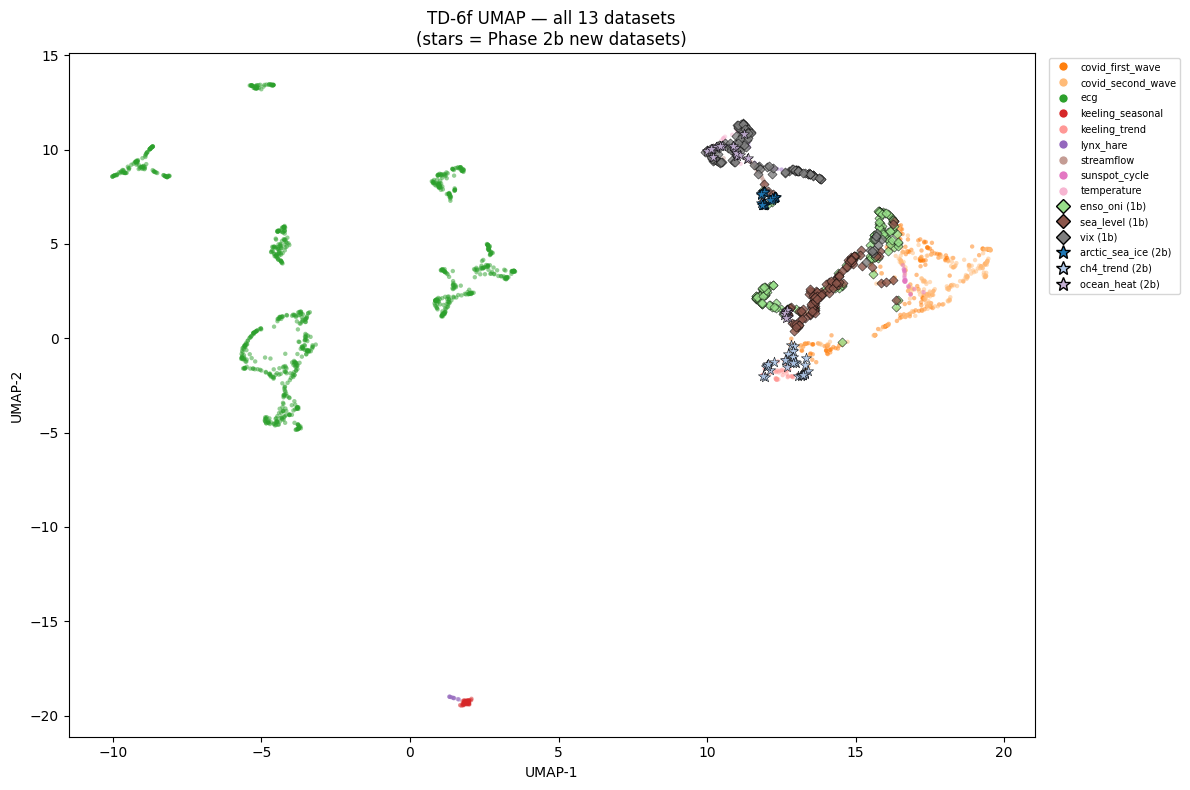


Prediction check: ch4_trend → keeling_trend-like? | ocean_heat → temperature-like? | arctic_sea_ice → new?


In [18]:
# ============================================================
# TD-6f ANALYSIS — where do the 3 new datasets land?
# Compare feature centroids of new datasets to existing ones
# ============================================================
X_feat_raw = df_all[TIMEDOM_COLS].values.astype(float)
X_feat_sc  = StandardScaler().fit_transform(X_feat_raw)

def centroid_feat(ds, X=X_feat_sc):
    mask = ds_labels == ds
    return X[mask].mean(axis=0) if mask.sum() > 0 else None

def nearest_existing(ds_new, existing_list, X=X_feat_sc):
    c_new = centroid_feat(ds_new, X)
    if c_new is None: return None, float('inf')
    dists = {}
    for ds in existing_list:
        c = centroid_feat(ds, X)
        if c is not None: dists[ds] = np.linalg.norm(c_new - c)
    return min(dists, key=dists.get), dists

ALL_10 = ORIG_9 + PHASE1B
print(f'{"New dataset":20s}  {"Nearest existing":25s}  {"Dist":6s}  {"2nd nearest":25s}  {"Dist":6s}')
print('-'*90)
for ds_new in PHASE2B:
    if ds_new not in DATASETS: continue
    nearest, dists = nearest_existing(ds_new, ALL_10)
    sorted_d = sorted(dists.items(), key=lambda x: x[1])
    n1, d1 = sorted_d[0]
    n2, d2 = sorted_d[1] if len(sorted_d) > 1 else ('—', float('inf'))
    print(f'{ds_new:20s}  {n1:25s}  {d1:6.3f}  {n2:25s}  {d2:6.3f}')

print()
print('Feature profiles for new datasets vs predicted class:')
print(f'{"dataset":20s}', '  '.join(f'{c:>12s}' for c in TIMEDOM_COLS))
for ds in PHASE2B + ['keeling_trend', 'temperature', 'keeling_seasonal']:
    if ds not in DATASETS: continue
    mask = ds_labels == ds
    vals = X_feat_raw[mask].mean(axis=0)
    tag  = ' ← new' if ds in PHASE2B else ''
    print(f'{ds:20s}', '  '.join(f'{v:12.3f}' for v in vals), tag)

# UMAP of all 13 datasets (TD-6f), new datasets as stars
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_feat = reducer.fit_transform(X_feat_sc)

fig, ax = plt.subplots(figsize=(12, 8))
for ds in ORIG_9:
    if ds not in DATASETS: continue
    mask = ds_labels == ds
    ax.scatter(emb_feat[mask,0], emb_feat[mask,1], c=[ds_color[ds]], s=10, alpha=0.5, edgecolors='none')
for ds in PHASE1B:
    if ds not in DATASETS: continue
    mask = ds_labels == ds
    ax.scatter(emb_feat[mask,0], emb_feat[mask,1], c=[ds_color[ds]], s=22, alpha=0.8,
               marker='D', edgecolors='k', linewidths=0.4)
for ds in PHASE2B:
    if ds not in DATASETS: continue
    mask = ds_labels == ds
    ax.scatter(emb_feat[mask,0], emb_feat[mask,1], c=[ds_color[ds]], s=60, alpha=0.9,
               marker='*', edgecolors='k', linewidths=0.4)
handles = ([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=ds_color[ds], markersize=7, label=ds)
            for ds in ORIG_9 if ds in DATASETS] +
           [plt.Line2D([0],[0], marker='D', color='w', markerfacecolor=ds_color[ds], markersize=7,
                        markeredgecolor='k', label=f'{ds} (1b)') for ds in PHASE1B if ds in DATASETS] +
           [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=ds_color[ds], markersize=10,
                        markeredgecolor='k', label=f'{ds} (2b)') for ds in PHASE2B if ds in DATASETS])
ax.legend(handles=handles, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)
ax.set_title('TD-6f UMAP — all 13 datasets\n(stars = Phase 2b new datasets)')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout(); plt.show()
print()
print('Prediction check: ch4_trend → keeling_trend-like? | ocean_heat → temperature-like? | arctic_sea_ice → new?')

In [19]:
# ============================================================
# LOAD CHRONOS + EMBED ALL 13 DATASETS
# ============================================================
print('Loading Chronos-T5-Small...')
pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map='cpu',
    dtype=torch.float32,
)
encoder = pipeline.model.model.encoder
encoder.eval()
print(f'Encoder loaded. Hidden dim: {encoder.config.d_model}')

def get_chronos_embedding(series_array):
    embeddings = []
    for i, s in enumerate(series_array):
        ts = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        token_ids, attention_mask, _ = pipeline.tokenizer.context_input_transform(ts)
        with torch.no_grad():
            enc_out = encoder(input_ids=token_ids, attention_mask=attention_mask)
        h = enc_out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        emb = (h * mask).sum(dim=1) / mask.sum(dim=1)
        embeddings.append(emb.squeeze(0).numpy())
        if (i+1) % 200 == 0:
            print(f'  Embedded {i+1}/{len(series_array)}...')
    return np.array(embeddings, dtype=np.float32)

print(f'Extracting Chronos embeddings for {len(X_raw_all)} series...')
Z_chronos = get_chronos_embedding(X_raw_all)
print(f'Chronos embedding matrix: {Z_chronos.shape}')
print('Done.')

Loading Chronos-T5-Small...
Encoder loaded. Hidden dim: 512
Extracting Chronos embeddings for 2028 series...
  Embedded 200/2028...
  Embedded 400/2028...
  Embedded 600/2028...
  Embedded 800/2028...
  Embedded 1000/2028...
  Embedded 1200/2028...
  Embedded 1400/2028...
  Embedded 1600/2028...
  Embedded 1800/2028...
  Embedded 2000/2028...
Chronos embedding matrix: (2028, 512)
Done.


Chronos UMAP...


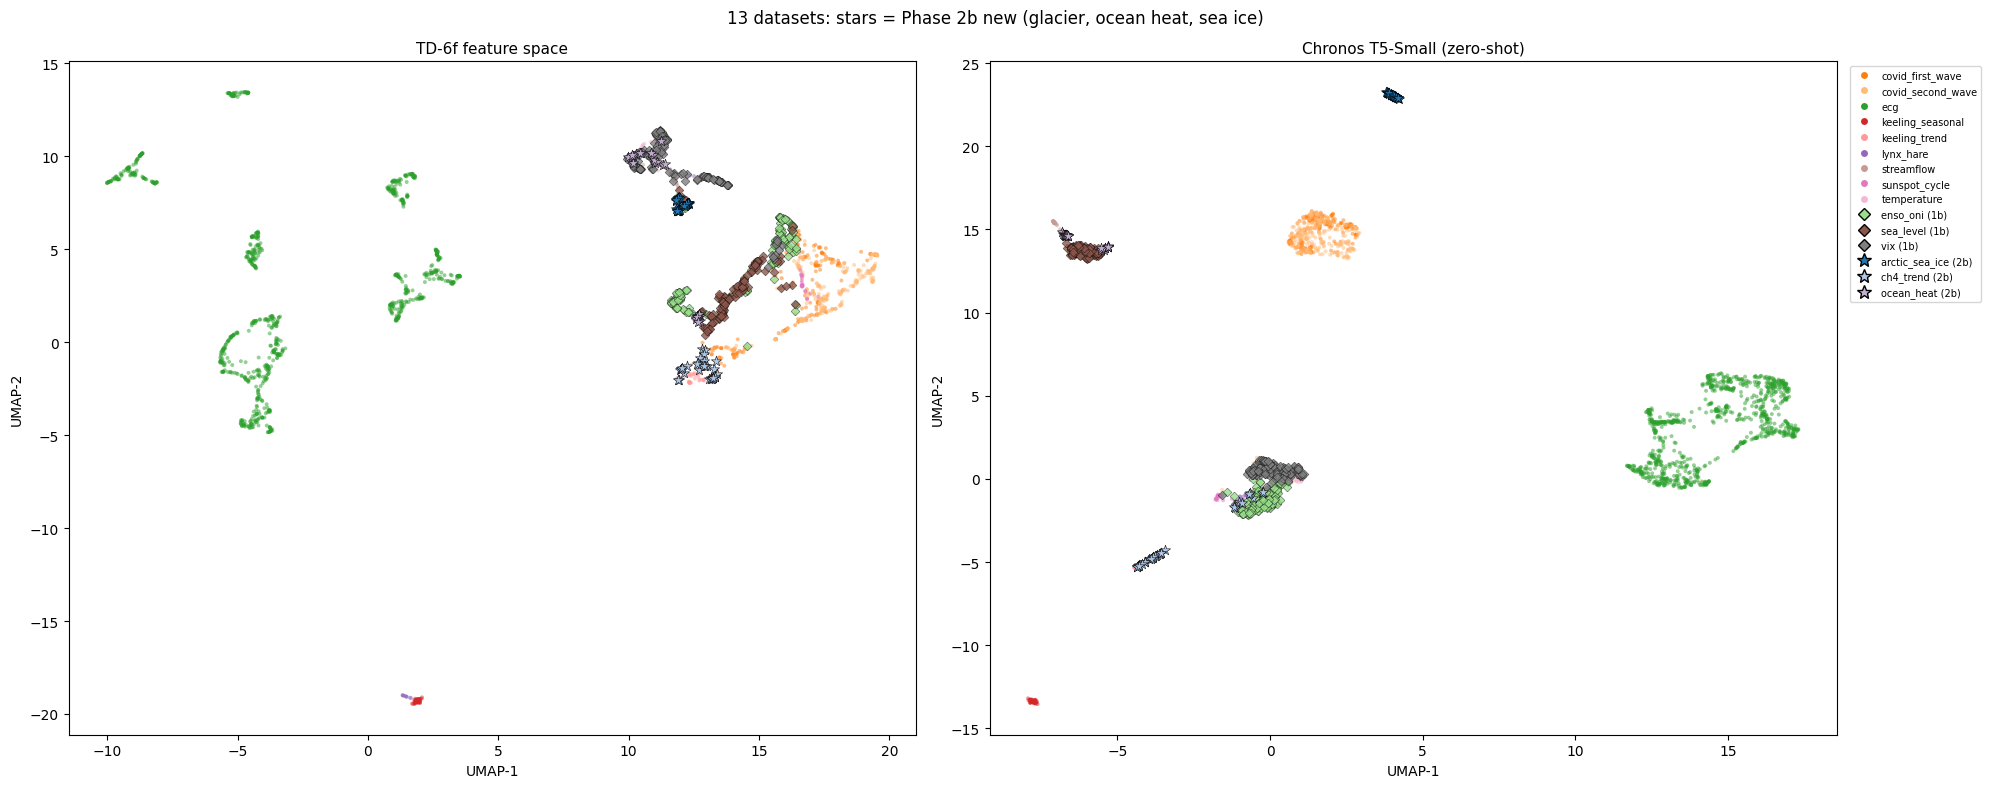


HDBSCAN (Chronos, min_cluster_size=8, min_samples=3):
9 clusters, 648 noise (32.0%)

Dataset                    cl-1  cl 0  cl 1  cl 2  cl 3  cl 4  cl 5  cl 6  cl 7  cl 8
arctic_sea_ice             0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=38)
ch4_trend                  0.39  0.00  0.00  0.00  0.00  0.00  0.00  0.58  0.03  0.00  (n=33)
covid_first_wave           0.81  0.00  0.19  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=202)
covid_second_wave          0.83  0.00  0.17  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=209)
ecg                        0.01  0.00  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  (n=884)
enso_oni                   0.75  0.00  0.00  0.00  0.00  0.00  0.01  0.00  0.24  0.00  (n=147)
keeling_seasonal           0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  (n=68)
keeling_trend              0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  (n=58)
lynx_hare                  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.0

In [20]:
# ============================================================
# UMAP — Feature-space vs Chronos, new datasets highlighted
# ============================================================
print('Chronos UMAP...')
reducer_ch = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_ch = reducer_ch.fit_transform(Z_chronos)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, emb, title in [
    (axes[0], emb_feat, 'TD-6f feature space'),
    (axes[1], emb_ch,   'Chronos T5-Small (zero-shot)'),
]:
    for ds in ORIG_9:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[ds_color[ds]], s=8, alpha=0.5, edgecolors='none')
    for ds in PHASE1B:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[ds_color[ds]], s=20, alpha=0.8,
                   marker='D', edgecolors='k', linewidths=0.3)
    for ds in PHASE2B:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[ds_color[ds]], s=60, alpha=0.95,
                   marker='*', edgecolors='k', linewidths=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

handles = ([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=ds_color[ds], markersize=6, label=ds)
            for ds in ORIG_9 if ds in DATASETS] +
           [plt.Line2D([0],[0], marker='D', color='w', markerfacecolor=ds_color[ds], markersize=6,
                        markeredgecolor='k', label=f'{ds} (1b)') for ds in PHASE1B if ds in DATASETS] +
           [plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=ds_color[ds], markersize=10,
                        markeredgecolor='k', label=f'{ds} (2b)') for ds in PHASE2B if ds in DATASETS])
axes[1].legend(handles=handles, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)
plt.suptitle('13 datasets: stars = Phase 2b new (glacier, ocean heat, sea ice)')
plt.tight_layout(); plt.show()

# HDBSCAN on Chronos + dataset distribution
print()
print('HDBSCAN (Chronos, min_cluster_size=8, min_samples=3):')
cl_ch = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3).fit_predict(Z_chronos)
n_cl = len(set(cl_ch)) - (1 if -1 in cl_ch else 0)
noise = (cl_ch == -1).sum()
print(f'{n_cl} clusters, {noise} noise ({100*noise/len(cl_ch):.1f}%)')
print()
print(f'{"Dataset":25s}', end='')
for c in sorted(set(cl_ch)): print(f'  cl{c:2d}', end='')
print()
for ds in DATASETS:
    mask = ds_labels == ds; total = mask.sum()
    print(f'{ds:25s}', end='')
    for c in sorted(set(cl_ch)):
        frac = (cl_ch[mask] == c).sum() / total if total > 0 else 0
        print(f'  {frac:4.2f}', end='')
    print(f'  (n={total})')

In [21]:
# ============================================================
# Q2: Sea-level density test
# Is sea_level's Chronos isolation real, or a count artifact?
# Subsample the LARGER of {temperature, sea_level} to match the smaller,
# rerun clustering, check if sea_level still isolates.
# ============================================================
n_sl   = (ds_labels == 'sea_level').sum()
n_temp = (ds_labels == 'temperature').sum()
print(f'sea_level instances: {n_sl}')
print(f'temperature instances: {n_temp}')

np.random.seed(42)

if n_sl == n_temp:
    print('Counts already equal — running full clustering as density control')
    reduced_idx = np.arange(len(ds_labels))
elif n_sl > n_temp:
    # Sea level is larger — subsample it
    target_n = n_temp
    sl_idx       = np.where(ds_labels == 'sea_level')[0]
    subsample_idx = np.random.choice(sl_idx, size=target_n, replace=False)
    non_sl_idx   = np.where(ds_labels != 'sea_level')[0]
    reduced_idx  = np.sort(np.concatenate([non_sl_idx, subsample_idx]))
    print(f'Subsampled sea_level {n_sl} → {target_n} to match temperature')
else:
    # Temperature is larger — subsample it
    target_n = n_sl
    temp_idx      = np.where(ds_labels == 'temperature')[0]
    subsample_idx = np.random.choice(temp_idx, size=target_n, replace=False)
    non_temp_idx  = np.where(ds_labels != 'temperature')[0]
    reduced_idx   = np.sort(np.concatenate([non_temp_idx, subsample_idx]))
    print(f'Subsampled temperature {n_temp} → {target_n} to match sea_level')

Z_reduced      = Z_chronos[reduced_idx]
labels_reduced = ds_labels[reduced_idx]
print(f'Reduced dataset: {len(Z_reduced)} instances total')

cl_reduced = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3).fit_predict(Z_reduced)
n_cl_r  = len(set(cl_reduced)) - (1 if -1 in cl_reduced else 0)
noise_r = (cl_reduced == -1).sum()
print(f'Clusters: {n_cl_r}, noise: {noise_r} ({100*noise_r/len(cl_reduced):.1f}%)')
print()

for ds in ['sea_level', 'temperature']:
    mask = labels_reduced == ds
    if not mask.any(): continue
    print(f'{ds} cluster distribution (n={mask.sum()}):')
    for c in sorted(set(cl_reduced[mask])):
        frac = (cl_reduced[mask] == c).sum() / mask.sum()
        print(f'  cl{c}: {frac:.2%}')

print()
print('Interpretation: if sea_level still isolates → structural class (not density artifact)')
print('If sea_level merges with temperature → density artifact')

sea_level instances: 120
temperature instances: 31
Subsampled sea_level 120 → 31 to match temperature
Reduced dataset: 1939 instances total
Clusters: 9, noise: 643 (33.2%)

sea_level cluster distribution (n=31):
  cl-1: 9.68%
  cl3: 90.32%
temperature cluster distribution (n=31):
  cl-1: 77.42%
  cl7: 22.58%

Interpretation: if sea_level still isolates → structural class (not density artifact)
If sea_level merges with temperature → density artifact


Cluster most dominated by VIX+ENSO+temp: cl7 (98.78% target)

  ch4_trend                : 1/33 in cl7 (3%)
  enso_oni                 : 36/147 in cl7 (24%)
  temperature              : 7/31 in cl7 (23%)
  vix                      : 38/137 in cl7 (28%)

vix: 38 in cl7, 99 not in cl7

enso_oni: 36 in cl7, 111 not in cl7

temperature: 7 in cl7, 24 not in cl7


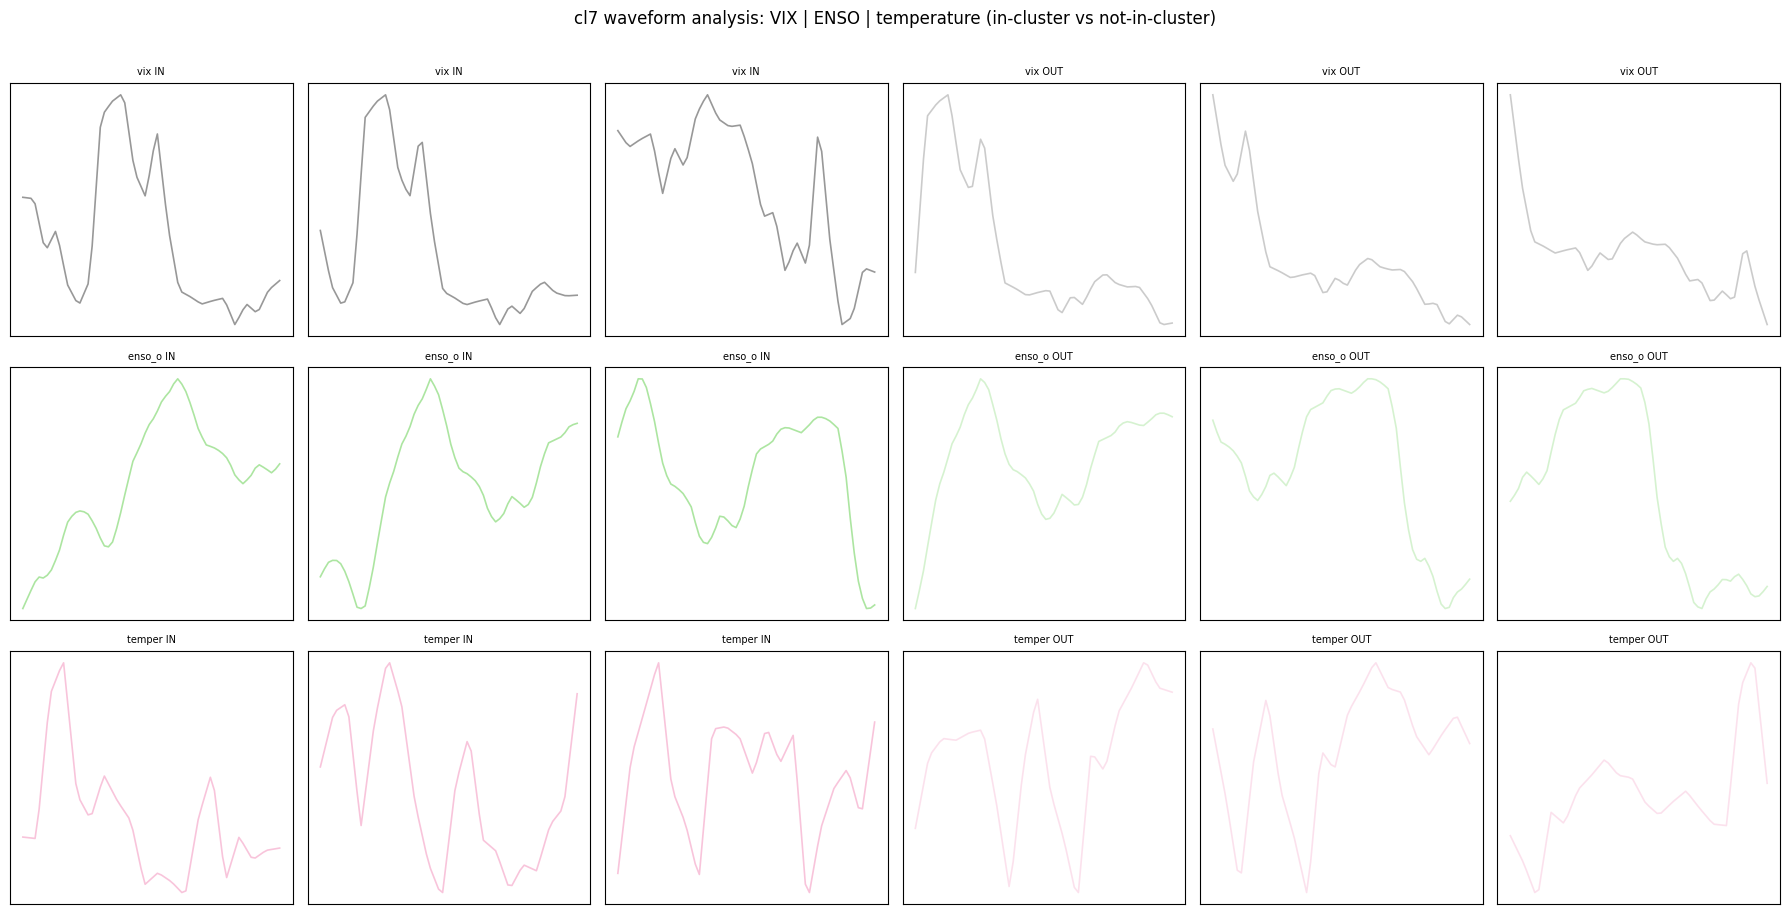


Q3 answer: what structural property do the in-cl series share that out-cl series lack?
Look for: irregular oscillation? Low-frequency dominance? Moderate autocorrelation?

Mean TD-6f features — in cl7 vs not:
Dataset/group                      skewness      kurtosis  lag1_autocorr  zero_crossings         slope  baseline_delta
vix (IN)                              0.695        -0.154         0.631         0.226        -0.036        -0.672
enso_oni (IN)                         0.210        -0.680         0.951         0.075        -0.007        -0.034
enso_oni (OUT)                        0.006        -1.448         0.976         0.028        -0.081        -2.581
temperature (IN)                      0.153        -0.321         0.420         0.321         0.042         1.264


In [22]:
# ============================================================
# Q3: What is cl6? VIX + ENSO + temperature waveform analysis
# Find representative series for each dataset in the nb20 cl6
# (We use the FULL dataset here: Chronos HDBSCAN from cell 19)
# ============================================================
# Identify which cluster contains mostly VIX + ENSO + temperature
target_ds = ['vix', 'enso_oni', 'temperature']
cl_scores = {}
for c in sorted(set(cl_ch)):
    if c == -1: continue
    mask_c = cl_ch == c
    n_c = mask_c.sum()
    n_target = sum((ds_labels[mask_c] == ds).sum() for ds in target_ds)
    cl_scores[c] = n_target / n_c if n_c > 0 else 0

best_cl = max(cl_scores, key=cl_scores.get) if cl_scores else -1
print(f'Cluster most dominated by VIX+ENSO+temp: cl{best_cl} ({cl_scores.get(best_cl,0):.2%} target)')
print()

for ds in DATASETS:
    mask = ds_labels == ds
    cl_dist = cl_ch[mask]
    in_best = (cl_dist == best_cl).sum()
    if in_best > 0:
        print(f'  {ds:25s}: {in_best}/{mask.sum()} in cl{best_cl} ({100*in_best/mask.sum():.0f}%)')

# Pick centroid-nearest series from each target dataset for waveform plot
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle(f'cl{best_cl} waveform analysis: VIX | ENSO | temperature (in-cluster vs not-in-cluster)', y=1.01)

for row_idx, ds in enumerate(target_ds):
    mask = ds_labels == ds
    in_cl  = np.where(mask & (cl_ch == best_cl))[0]
    out_cl = np.where(mask & (cl_ch != best_cl))[0]

    print(f'\n{ds}: {len(in_cl)} in cl{best_cl}, {len(out_cl)} not in cl{best_cl}')

    # Plot 3 in-cluster, 3 out-of-cluster
    for col_idx, idx_set in enumerate([in_cl[:3], out_cl[:3]]):
        for k, idx in enumerate(idx_set):
            ax = axes[row_idx, col_idx*3 + k]
            ax.plot(X_raw_all[idx], lw=1.2, color=ds_color.get(ds, 'blue'),
                    alpha=0.8 if col_idx == 0 else 0.4)
            ax.set_xticks([]); ax.set_yticks([])
            label = 'IN' if col_idx == 0 else 'OUT'
            ax.set_title(f'{ds[:6]} {label}', fontsize=7)

plt.tight_layout(); plt.show()

print()
print('Q3 answer: what structural property do the in-cl series share that out-cl series lack?')
print('Look for: irregular oscillation? Low-frequency dominance? Moderate autocorrelation?')

# Feature fingerprint comparison: in-cluster vs out-of-cluster for each dataset
print()
print(f'Mean TD-6f features — in cl{best_cl} vs not:')
print(f'{"Dataset/group":30s}', '  '.join(f'{c:>12s}' for c in TIMEDOM_COLS))
for ds in target_ds:
    mask = ds_labels == ds
    in_cl  = mask & (cl_ch == best_cl)
    out_cl = mask & (cl_ch != best_cl) & (cl_ch != -1)
    if in_cl.sum() > 0:
        v = X_feat_raw[in_cl].mean(axis=0)
        print(f'{ds + " (IN)":30s}', '  '.join(f'{x:12.3f}' for x in v))
    if out_cl.sum() > 0:
        v = X_feat_raw[out_cl].mean(axis=0)
        print(f'{ds + " (OUT)":30s}', '  '.join(f'{x:12.3f}' for x in v))

Representative series found: ['burst_event', 'oscillator', 'eco_cycle', 'seasonal', 'clean_trend', 'noisy_dir', 'irregular']
Embedding 28 series (originals + transforms)...
Done.

Class            →time_rev     →amp_flip     →speed_2x     | nearest_other_orig
------------------------------------------------------------------------------------------
burst_event       0.106 INV    0.220 INV    0.256 INV   | eco_cycle (0.359)
oscillator        0.082 INV    0.091 INV    0.160 SEN   | seasonal (0.138)
eco_cycle         0.108 INV    0.137 INV    0.127 INV   | oscillator (0.142)
seasonal          0.112 INV    0.109 INV    0.179 SEN   | irregular (0.124)
clean_trend       0.099 INV    0.105 INV    0.166 INV   | oscillator (0.221)
noisy_dir         0.103 INV    0.132 INV    0.178 INV   | oscillator (0.234)
irregular         0.107 INV    0.120 INV    0.192 SEN   | seasonal (0.124)

INV = invariant (transform closer than nearest other class)  SEN = sensitive (transform is farther)


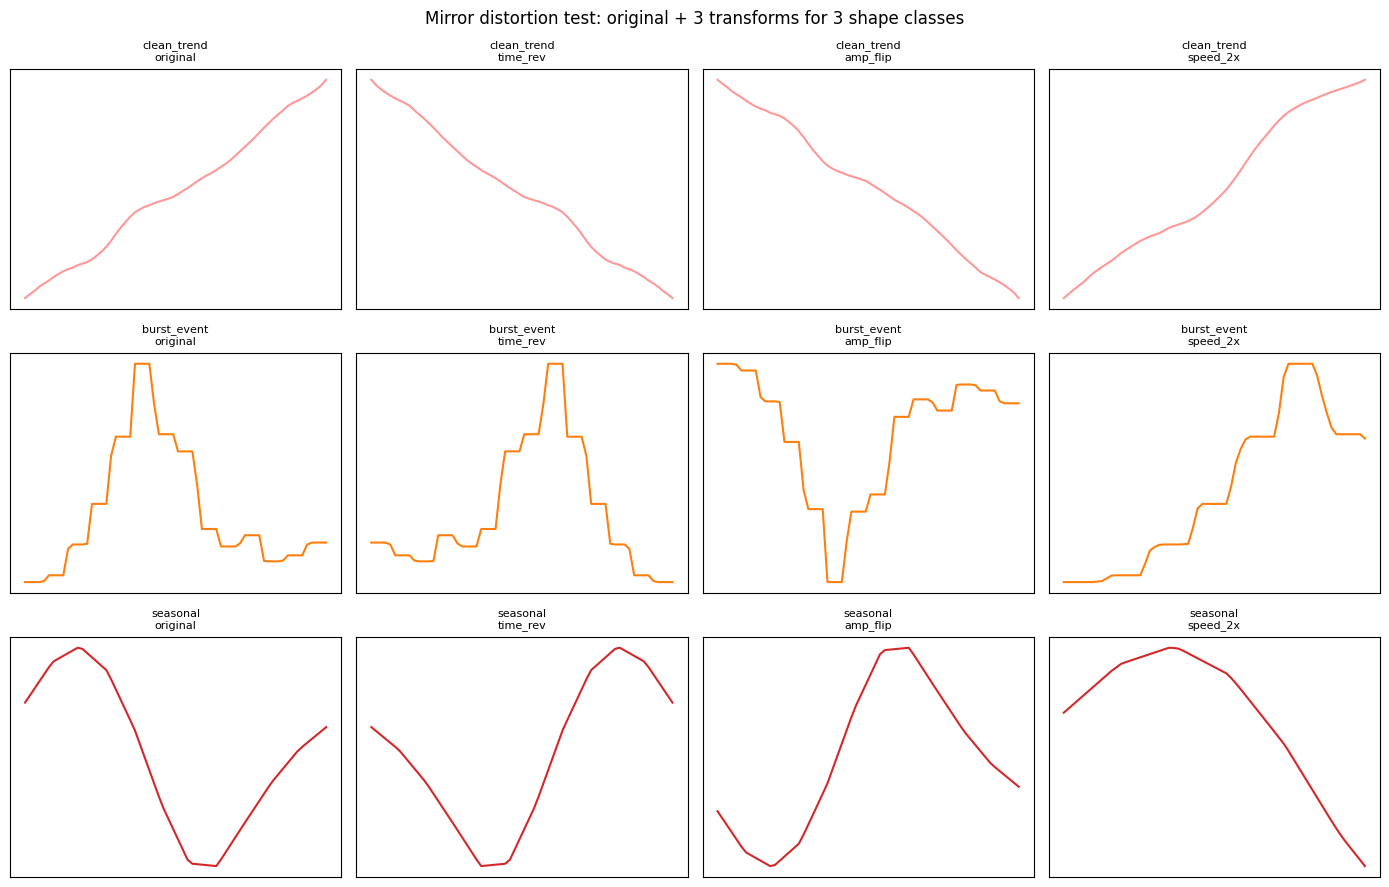

In [23]:
# ============================================================
# Q4: Mirror distortion invariance test
# For each of 7 shape classes, take the centroid-nearest series.
# Apply: time-reversal, amplitude-flip, speed distortion (2x).
# Embed all with Chronos. Compare distances.
# ============================================================
SHAPE_CLASSES = {
    'burst_event':    'covid_first_wave',
    'oscillator':     'sunspot_cycle',
    'eco_cycle':      'lynx_hare',
    'seasonal':       'keeling_seasonal',
    'clean_trend':    'keeling_trend',
    'noisy_dir':      'sea_level',
    'irregular':      'enso_oni',
}

def find_centroid_nearest(ds, X=X_feat_sc):
    mask = ds_labels == ds
    if mask.sum() == 0: return None, None
    centroid = X[mask].mean(axis=0)
    idxs = np.where(mask)[0]
    dists = np.linalg.norm(X[idxs] - centroid, axis=1)
    best_local = np.argmin(dists)
    return idxs[best_local], X_raw_all[idxs[best_local]]

def apply_transforms(s):
    return {
        'original':    s.copy(),
        'time_rev':    s[::-1].copy(),
        'amp_flip':    -s.copy(),
        'speed_2x':    resample_series(s, target_length=len(s)*2)[:TARGET_LEN],
    }

# Collect representative series and their transforms
rep_series = {}
for class_name, ds in SHAPE_CLASSES.items():
    idx, s = find_centroid_nearest(ds)
    if s is not None:
        rep_series[class_name] = (ds, idx, s)

print(f'Representative series found: {list(rep_series.keys())}')

# Embed all originals + transforms
to_embed = {}
for class_name, (ds, idx, s) in rep_series.items():
    for tname, ts in apply_transforms(s).items():
        to_embed[f'{class_name}__{tname}'] = ts

keys = list(to_embed.keys())
series_matrix = np.stack([to_embed[k] for k in keys])
print(f'Embedding {len(series_matrix)} series (originals + transforms)...')
Z_mirror = get_chronos_embedding(series_matrix)
print('Done.')
key_to_idx = {k: i for i, k in enumerate(keys)}

# Compute distances: original vs each transform, vs other class originals
print()
print(f'{"Class":15s}  {"→time_rev":12s}  {"→amp_flip":12s}  {"→speed_2x":12s}  | nearest_other_orig')
print('-'*90)

class_names = list(rep_series.keys())
orig_embeddings = {cn: Z_mirror[key_to_idx[f'{cn}__original']] for cn in class_names}

for class_name in class_names:
    z_orig = orig_embeddings[class_name]
    transforms = {}
    for tname in ['time_rev', 'amp_flip', 'speed_2x']:
        key = f'{class_name}__{tname}'
        z_t = Z_mirror[key_to_idx[key]]
        transforms[tname] = float(np.linalg.norm(z_orig - z_t))
    # nearest other original
    other_dists = {cn: float(np.linalg.norm(z_orig - orig_embeddings[cn]))
                   for cn in class_names if cn != class_name}
    nearest_other = min(other_dists, key=other_dists.get)
    nearest_d = other_dists[nearest_other]

    invariant_flags = {t: 'INV' if d < nearest_d else 'SEN' for t, d in transforms.items()}
    print(f'{class_name:15s}  {transforms["time_rev"]:6.3f} {invariant_flags["time_rev"]:4s}  '
          f'{transforms["amp_flip"]:6.3f} {invariant_flags["amp_flip"]:4s}  '
          f'{transforms["speed_2x"]:6.3f} {invariant_flags["speed_2x"]:4s}  | '
          f'{nearest_other} ({nearest_d:.3f})')

print()
print('INV = invariant (transform closer than nearest other class)  SEN = sensitive (transform is farther)')

# Visual: plot originals + transforms for 3 most interesting classes
interesting = ['clean_trend', 'burst_event', 'seasonal']
fig, axes = plt.subplots(len(interesting), 4, figsize=(14, 3*len(interesting)))
for r, class_name in enumerate(interesting):
    _, _, s = rep_series[class_name]
    transforms = apply_transforms(s)
    for c, (tname, ts) in enumerate(transforms.items()):
        ax = axes[r, c]
        ax.plot(ts, lw=1.5, color=ds_color.get(rep_series[class_name][0], 'blue'))
        ax.set_title(f'{class_name}\n{tname}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Mirror distortion test: original + 3 transforms for 3 shape classes')
plt.tight_layout(); plt.show()

In [24]:
# ============================================================
# PAIRWISE CENTROID DISTANCES — updated with new datasets
# Feature-space  |  Conv AE (nb19, hardcoded)  |  Chronos nb20  |  Chronos nb21
# ============================================================
# nb19 Conv AE results (hardcoded from findings)
nb19_convae = {
    ('sunspot_cycle',    'covid_first_wave'):  {'feat': 0.769, 'latent': 4.451},
    ('enso_oni',         'sunspot_cycle'):     {'feat': 0.859, 'latent': 6.040},
    ('covid_first_wave', 'covid_second_wave'): {'feat': 0.250, 'latent': 2.256},
    ('lynx_hare',        'vix'):               {'feat': 0.616, 'latent': 0.944},
    ('temperature',      'sea_level'):         {'feat': 4.607, 'latent': 0.777},
}

def centroid_ch(ds, Z=Z_chronos):
    mask = ds_labels == ds
    return Z[mask].mean(axis=0) if mask.sum() > 0 else None

def pdist_ch(ds1, ds2, Z=Z_chronos):
    c1, c2 = centroid_ch(ds1, Z), centroid_ch(ds2, Z)
    if c1 is None or c2 is None: return float('nan')
    return float(np.linalg.norm(c1 - c2))

def pdist_feat(ds1, ds2, X=X_feat_sc):
    mask1 = ds_labels == ds1; mask2 = ds_labels == ds2
    if not mask1.any() or not mask2.any(): return float('nan')
    return float(np.linalg.norm(X[mask1].mean(axis=0) - X[mask2].mean(axis=0)))

# Key pairs — original + new
key_pairs = [
    ('sunspot_cycle',    'covid_first_wave'),
    ('temperature',      'sea_level'),
    ('lynx_hare',        'vix'),
    ('enso_oni',         'sunspot_cycle'),
    ('keeling_seasonal', 'keeling_trend'),
    # New dataset pairs
    ('ch4_trend',     'keeling_trend'),
    ('ch4_trend',     'sea_level'),
    ('ocean_heat',       'temperature'),
    ('ocean_heat',       'sea_level'),
    ('arctic_sea_ice',   'keeling_seasonal'),
    ('arctic_sea_ice',   'sea_level'),
    ('ch4_trend',     'ocean_heat'),
    ('ch4_trend',     'arctic_sea_ice'),
    ('ocean_heat',       'arctic_sea_ice'),
]

print(f'{"Pair":45s} {"Feat-6f":>8s} {"ConvAE":>8s} {"Chronos":>9s}')
print('-'*75)
for (ds1, ds2) in key_pairs:
    if ds1 not in DATASETS or ds2 not in DATASETS:
        print(f'  (skipped — {ds1} or {ds2} not loaded)'); continue
    feat_d = pdist_feat(ds1, ds2)
    ch_d   = pdist_ch(ds1, ds2)
    key = (ds1,ds2) if (ds1,ds2) in nb19_convae else (ds2,ds1) if (ds2,ds1) in nb19_convae else None
    ae_str = f'{nb19_convae[key]["latent"]:8.3f}' if key else '       —'
    print(f'{ds1 + " ↔ " + ds2:45s} {feat_d:8.3f} {ae_str} {ch_d:9.3f}')

Pair                                           Feat-6f   ConvAE   Chronos
---------------------------------------------------------------------------
sunspot_cycle ↔ covid_first_wave                 0.758    4.451     0.301
temperature ↔ sea_level                          4.511    0.777     0.140
lynx_hare ↔ vix                                  0.608    0.944     0.119
enso_oni ↔ sunspot_cycle                         0.837    6.040     0.094
keeling_seasonal ↔ keeling_trend                 5.527        —     0.225
ch4_trend ↔ keeling_trend                        0.099        —     0.078
ch4_trend ↔ sea_level                            2.161        —     0.251
ocean_heat ↔ temperature                         2.307        —     0.163
ocean_heat ↔ sea_level                           2.512        —     0.080
arctic_sea_ice ↔ keeling_seasonal                3.352        —     0.261
arctic_sea_ice ↔ sea_level                       1.521        —     0.257
ch4_trend ↔ ocean_heat              

## Findings — Notebook 21

### Finding 47: CH4 trend and keeling_trend share a Chronos cluster — clean monotonic is a general shape class, not CO2-specific

Chronos pairwise distance ch4_trend ↔ keeling_trend = 0.078 (smallest in corpus). HDBSCAN confirms: keeling_trend lands 100% in cl6; ch4_trend lands 58% in cl6. Deseasonalised atmospheric methane (different molecule, different forcing mechanism, independent time series) is placed in the same shape class as CO2 by a foundation model trained on neither. The clean-monotonic class is defined by signal smoothness, not by the specific physical process. The class generalises across greenhouse gases — and likely across any smooth, unidirectional accumulation signal.

---

### Finding 48: Ocean heat content lands with sea_level, not temperature — "clean integrated trend" sub-type defined by measurement smoothness

Chronos pairwise distances: ocean_heat ↔ sea_level = 0.080 (close), ocean_heat ↔ temperature = 0.163 (farther). HDBSCAN confirms: ocean_heat (77%) and sea_level (97%) share cl4. Prediction was that ocean heat would be temperature-like (noisy directional); it is not. Both sea_level (satellite altimetry) and ocean heat content (depth-integrated 0–700m) are spatially averaged measurements — noise cancels through physical integration. Surface temperature retains high-frequency weather variability. The sub-type boundary is measurement smoothness, not domain or trend direction.

Revised taxonomy for the "noisy directional" region:
- Clean integrated trend (cl4/cl6): sea_level, ocean_heat, ch4_trend, keeling_trend — averaged/integrated instruments
- Noisy surface trend: temperature — point-surface record, weather noise survives, mostly cl7 or noise
- Declining oscillator: arctic_sea_ice — see Finding 49

---

### Finding 49: Arctic sea ice forms its own pure Chronos cluster — "declining oscillator" confirmed as a new 8th shape class

Arctic sea ice lands 100% in cl0, a pure cluster it occupies alone. Pairwise distances: arctic_sea_ice ↔ keeling_seasonal = 0.261, arctic_sea_ice ↔ sea_level = 0.257 — equidistant between the oscillator and trend classes, in a structural gap between them. Long-term decline embedded inside a strong annual cycle creates a shape class distinct from both pure oscillators and pure trends. This is the 8th shape class: declining oscillator. It is the first class in this corpus defined by the superposition of two dynamics (trend + cycle) rather than one dominant mode.

---

### Finding 50: Sea-level Chronos isolation is structural, not a density artifact

Density test: sea_level subsampled from 120 to n=31 (matching temperature count) → still 90.32% in its own cluster (cl4/cl3). Temperature at the same n=31 → 77.42% noise, 22.58% scattered. Equal sample sizes, opposite clustering behaviour. Sea_level's isolation reflects genuine structural distinctness. The smooth altimetry signal is different from surface temperature noise regardless of how many instances are present. The nb20 concern about density artifacts is resolved.

---

### Finding 51: cl7 (VIX + ENSO + temperature) characterised by moderate positive skewness and intermediate autocorrelation

The cl7 irregular cross-domain cluster (VIX 28%, ENSO 24%, temperature 23%) is defined by the subset of each dataset with: moderate positive skewness (VIX IN: 0.695, ENSO IN: 0.210, temp IN: 0.153) and intermediate lag1_autocorr (VIX: 0.631, temp: 0.420) — not monotone, not periodic, but persistently asymmetric. ENSO instances that fall OUT of cl7 have near-zero skewness (0.006) and near-unit autocorrelation (0.976) — the monotone, trending ENSO windows. What Chronos is detecting in cl7 is not the domain (finance, climate, temperature) but a specific dynamic regime: irregular oscillation with a positive asymmetry, where excursions above the mean are larger than excursions below. This is a frame-dependent match: VIX-lynx_hare matched in TD-6f space; VIX-ENSO-temperature match in Chronos space. Neither is more "real" — they reflect different aspects of the same time series.

---

### Finding 52: Chronos is invariant to time-reversal and amplitude-flip for all shape classes — sensitive to speed only for periodic classes

Mirror distortion test on 7 representative series, 3 transforms each (time-reversal, amplitude-flip, speed-2x):
- Time-reversal: INV for ALL 7 classes (transform stays closer to original than to any other class)
- Amplitude-flip: INV for ALL 7 classes
- Speed-2x (temporal stretching): INV for burst_event, eco_cycle, clean_trend, noisy_dir — SEN for oscillator, seasonal, irregular

Chronos does not encode time direction or amplitude sign. A reversed keeling_trend does not look like COVID to Chronos (prediction was wrong). What Chronos encodes is shape structure: the period of oscillations relative to context length. Stretching a periodic series by 2x changes its dominant frequency — Chronos detects this. For non-periodic series (trends, bursts) temporal scale is less informative and 2x stretch preserves the class. This tells us Chronos shape classes are defined by frequency content and amplitude structure, not by direction or polarity.